Basic Monte Carlo simulation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pandas_datareader import data as pdr


In [3]:
def monte_carlo_sims(df_stocks, weights):
    # Calculations needed for Monte Carlo
    returns = df_stocks.pct_change().dropna()
    meanReturns = returns.mean()
    covMatrix = returns.cov()
    returns['portfolio'] = returns.dot(weights)

    meanM = np.full(shape=(T, len(weights)), fill_value=meanReturns)
    meanM = meanM.T
    
    portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)
    
    for m in range(0, mc_sims):
        # MC loops
        Z = np.random.normal(size=(T, len(weights)))
        L = np.linalg.cholesky(covMatrix)
        dailyReturns = meanM + np.inner(L, Z)
        portfolio_sims[:,m] = np.cumprod(np.inner(weights, dailyReturns.T)+1)*initialPortfolio

    return portfolio_sims

def plot_monte_carlo(portfolio_sims):
    plt.plot(portfolio_sims)
    plt.ylabel('Portfolio Value ($)')
    plt.xlabel('Days')
    plt.title('MC simulation of a stock portfolio')
    plt.show()

In [4]:
def mcVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: percentile on return distribution to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        return np.percentile(returns, alpha)
    else:
        raise TypeError("Expected a pandas data series.")

def mcCVaR(returns, alpha=5):
    """ Input: pandas series of returns
        Output: CVaR or Expected Shortfall to a given confidence level alpha
    """
    if isinstance(returns, pd.Series):
        belowVaR = returns <= mcVaR(returns, alpha=alpha)
        return returns[belowVaR].mean()
    else:
        raise TypeError("Expected a pandas data series.")

In [5]:
df_stocks = pd.read_csv('df_cleaned.csv')

In [21]:
# Specify stocks
df_stocks_tech = df_stocks[['AAPL',
     'MSFT',
     'AMZN',
     'GOOGL',
     'META',
     'ORCL',
     'CRM',
     'ADBE',
     'IBM',
     'INTC',
     'NVDA',
     'CSCO']]

# Set weights
weights = np.random.random(len(df_stocks_tech.columns))
weights = np.ones(len(df_stocks_tech.columns))
weights /= np.sum(weights)


# Monte Carlo parameters
mc_sims = 4000 # number of simulations
T = 100 #timeframe in days
initialPortfolio = 10000

In [23]:
tech_stock_mc = monte_carlo_sims(df_stocks_tech, weights)

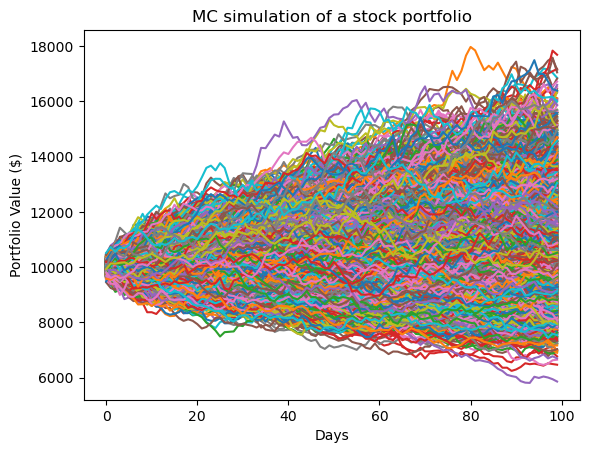

In [24]:
plot_monte_carlo(tech_stock_mc)

In [27]:
portResults = pd.Series(tech_stock_mc[-1,:])

VaR = initialPortfolio - mcVaR(portResults, alpha=5)
CVaR = initialPortfolio - mcCVaR(portResults, alpha=5)

print('VaR ${}'.format(round(VaR,2)))
print('CVaR ${}'.format(round(CVaR,2)))

VaR $1563.59
CVaR $2038.56


In [19]:
weights

array([0.13869163, 0.07007663, 0.14829413, 0.1309352 , 0.02200331,
       0.0599219 , 0.02680905, 0.04996711, 0.16823086, 0.09072343,
       0.06234236, 0.03200438])